# Multivariate Regression Epidemics

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
import os
cwd = os.getcwd()
print(cwd)

c:\Users\danie\Documents\GitHub\thesis\modelling


In [36]:
df = pd.read_csv('../Data/gold/epidemics.csv')
df.head()

,week,dengue,zika,chik,var,date,tavg,tmin,tmax,prcp,...,google_pharmacy,google_symptom,co,dew,humidity,no2,o3,pm10,pm25,so2
0,2020-03-23,949,3.0,1.0,351.0,2020-03-23,20.003080,14.529673,25.878470,1.866561,...,6,44,6.007143,11.964286,82.078571,7.164286,18.142857,48.857143,118.285714,0.742857
1,2020-03-30,1006,1.0,4.0,275.0,2020-03-30,20.310320,15.607637,25.801951,4.628407,...,6,40,5.992857,12.285714,79.671429,6.228571,13.057143,25.214286,63.214286,0.628571
2,2020-04-06,931,3.0,2.0,212.0,2020-04-06,20.567575,15.800335,25.874548,3.028124,...,6,38,4.335714,12.678571,79.557143,4.700000,11.757143,15.214286,37.285714,0.614286
3,2020-04-13,883,1.0,0.0,188.0,2020-04-13,19.564572,14.112981,25.608096,2.240946,...,5,31,5.028571,11.714286,82.707143,7.000000,12.092857,31.571429,74.785714,0.642857
4,2020-04-20,879,3.0,3.0,195.0,2020-04-20,19.833153,14.608703,25.966335,4.637722,...,5,29,5.207143,11.928571,83.142857,7.192857,9.607143,23.071429,53.500000,0.442857


In [37]:
import json
from pathlib import Path

# path to the JSON file
json_path = Path("..") / "Data" / "gold" / "features_dict.json"

# read it into a Python dict
with json_path.open("r", encoding="utf‑8") as f:
    features_dict = json.load(f)

# quick sanity check
print(f"Loaded {len(features_dict)} keys from features_dict.json")

Loaded 2 keys from features_dict.json


In [38]:
selected_features_epidemics = features_dict['dengue']
selected_features_epidemics

['dengue', 'pres', 'google_symptom', 'date_num', 'google_physician']

In [39]:
selected_features_epidemics
#selected_features_epidemics.extend(['date', 'zika', 'chik', 'var'])

['dengue', 'pres', 'google_symptom', 'date_num', 'google_physician']

# Wrangle

In [40]:
df.columns

Index(['week', 'dengue', 'zika', 'chik', 'var', 'date', 'tavg', 'tmin', 'tmax',
       'prcp', 'wdir', 'wspd', 'pres', 'mob_index', 'google_physician',
       'google_hospital', 'google_pharmacy', 'google_symptom', 'co', 'dew',
       'humidity', 'no2', 'o3', 'pm10', 'pm25', 'so2'],
      dtype='object')

In [41]:
df.rename(columns={'chik': 'chikungunya', 'var': 'varicella'}, inplace=True)

In [42]:
tarteg_cols = ['dengue', 'zika', 'chikungunya', 'varicella']
for col in tarteg_cols:
    df[col+'_1'] = df[col].shift(-1)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197 entries, 0 to 196
Data columns (total 30 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   week              197 non-null    object 
 1   dengue            197 non-null    int64  
 2   zika              197 non-null    float64
 3   chikungunya       197 non-null    float64
 4   varicella         197 non-null    float64
 5   date              197 non-null    object 
 6   tavg              197 non-null    float64
 7   tmin              197 non-null    float64
 8   tmax              197 non-null    float64
 9   prcp              197 non-null    float64
 10  wdir              197 non-null    float64
 11  wspd              197 non-null    float64
 12  pres              197 non-null    float64
 13  mob_index         197 non-null    float64
 14  google_physician  197 non-null    int64  
 15  google_hospital   197 non-null    int64  
 16  google_pharmacy   197 non-null    int64  
 1

In [44]:
# drop nans
df.dropna(subset=['dengue_1', 'zika_1', 'chikungunya_1', 'varicella_1'], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 196 entries, 0 to 195
Data columns (total 30 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   week              196 non-null    object 
 1   dengue            196 non-null    int64  
 2   zika              196 non-null    float64
 3   chikungunya       196 non-null    float64
 4   varicella         196 non-null    float64
 5   date              196 non-null    object 
 6   tavg              196 non-null    float64
 7   tmin              196 non-null    float64
 8   tmax              196 non-null    float64
 9   prcp              196 non-null    float64
 10  wdir              196 non-null    float64
 11  wspd              196 non-null    float64
 12  pres              196 non-null    float64
 13  mob_index         196 non-null    float64
 14  google_physician  196 non-null    int64  
 15  google_hospital   196 non-null    int64  
 16  google_pharmacy   196 non-null    int64  
 17  go

In [45]:
# convert date to numeric
df['date'] = pd.to_datetime(df['date'])
df['date_num'] = df['date'].apply(lambda x: x.timestamp())

In [46]:
selected_features_epidemics

['dengue', 'pres', 'google_symptom', 'date_num', 'google_physician']

In [ ]:
selected_features_epidemics.extend(['date', 'zika', 'chikungunya', 'varicella',
                                    'dengue_1', 'zika_1', 'chikungunya_1', 'varicella_1', 'pm25'])

In [48]:
df = df[selected_features_epidemics]

In [49]:
df_og = df.copy()

# Regression Framework

In [50]:
targets = ['dengue_1', 'zika_1', 'chikungunya_1', 'varicella_1']

## OLS

In [58]:

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model    import LinearRegression
from sklearn.metrics         import mean_squared_error, r2_score
df = df_og.copy()

          target        rmse        r2
0       dengue_1  178.527362  0.911771
1         zika_1    0.982037 -0.506869
2  chikungunya_1    1.110435 -0.029701
3    varicella_1   57.790402  0.863910
target      chikungunya_1    dengue_1  varicella_1    zika_1
date                                                        
2020-03-23       1.290057  864.166714   303.731730  1.461908
2020-03-30       1.889484  927.235518   242.490487  1.210601
2020-04-06       1.099240  878.267901   193.364235  0.866298
2020-04-13       0.797976  843.812730   178.253391  1.299833
2020-04-20       1.596566  835.909953   185.506468  1.468816


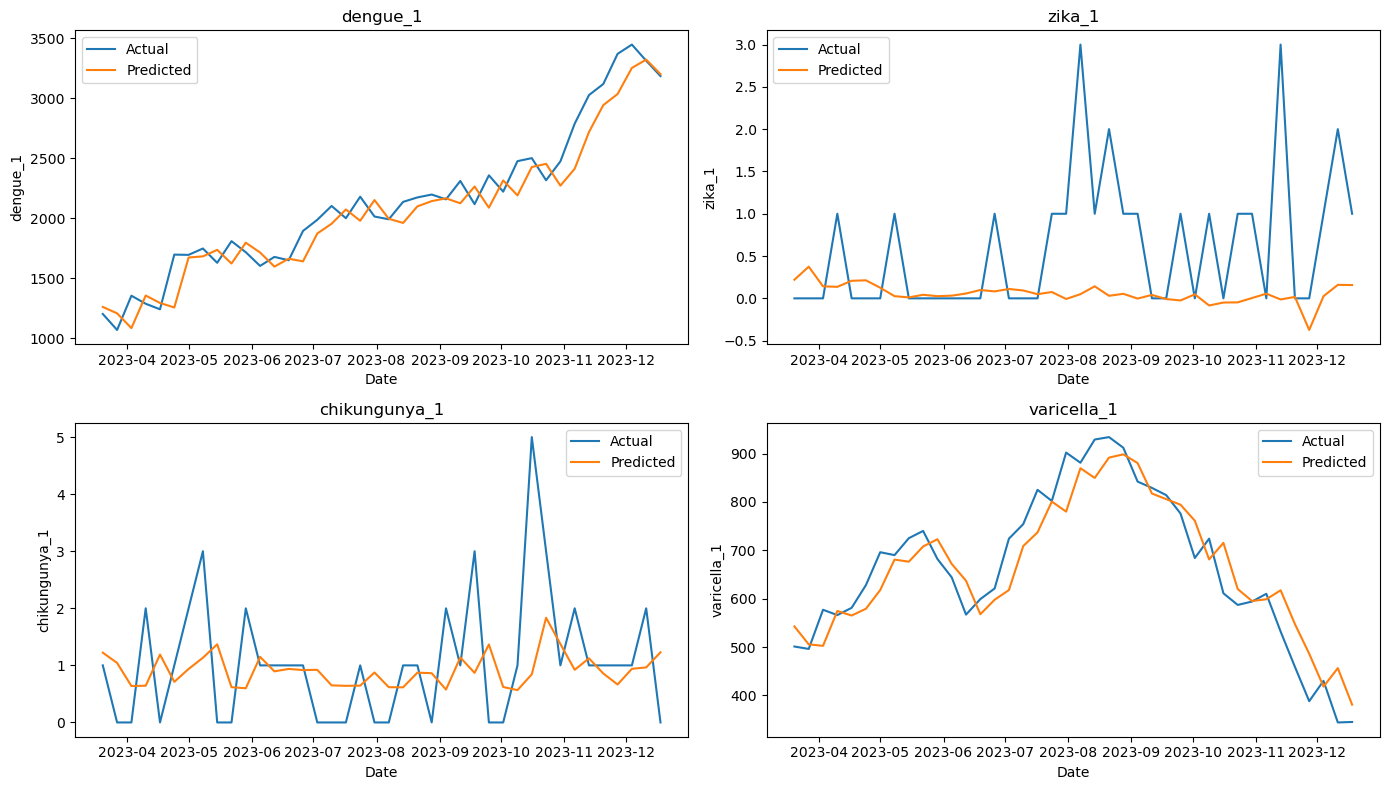

In [59]:


# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

targets = ['dengue_1', 'zika_1', 'chikungunya_1', 'varicella_1']
targets_lagged = {'dengue_1':'dengue',
                  'zika_1':'zika',
                  'chikungunya_1':'chikungunya',
                  'varicella_1':'varicella'}
targets_lagged_list = list(targets_lagged.values())

results       = []   # per‑target metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values for every row

# -------------------------------------------------------------
# 1.  Loop over target variables
# -------------------------------------------------------------
for tgt in targets:

    # ---- 1.1  Copy & drop rows where the current target is NaN
    df_tgt = df.copy()
    df_tgt = df_tgt.dropna(subset=[tgt]).sort_values('date').reset_index(drop=True)

    if len(df_tgt) < 20:                # tiny series? skip
        print(f"[{tgt}] skipped (only {len(df_tgt)} non‑NaN rows)")
        continue

    # ---- 1.2  Features / target
    y = df_tgt[tgt]
    X = (df_tgt
         .drop(columns=targets + ['date'])        # remove all target cols + date
         .select_dtypes(include='number'))        # numeric predictors only
    # drop epidemics that are not same as target
    targets_lagged_remove = targets_lagged_list.copy() # get a list of epidemics
    targets_lagged_remove.remove(targets_lagged[tgt]) # dont remove target epidemic (lagged)
    X = X.drop(columns=targets_lagged_remove) # remove other lagged epidemics
    

    # ---- 1.3  Time‑series split: last fold is hold‑out
    # outer_split = TimeSeriesSplit(n_splits=5)
    # train_idx, test_idx = list(outer_split.split(X))[-1]
    # ---- 2.3  Custom 80-20 chronological split
    split_point = int(len(X) * 0.8)          # 80 % train, 20 % test

    train_idx = np.arange(split_point)
    test_idx  = np.arange(split_point, len(X))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_tgt.loc[test_idx, 'date']

    # ---- 1.4  Fit OLS
    ols = LinearRegression()
    ols.fit(X_train, y_train)

    # ---- 1.5  Predict + metrics
    y_pred_test  = ols.predict(X_test)
    y_pred_train = ols.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({"target": tgt, "rmse": rmse, "r2": r2})

    plot_payload.append({
        "target": tgt,
        "date":   dates_test,
        "y_true": y_test,
        "y_pred": y_pred_test
    })

    # ---- 1.6  Collect fitted values (train + test) for this target
    y_hat_full = pd.Series(index=df_tgt.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":   df_tgt['date'],
            "target": tgt,
            "fitted": y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 2.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 3.  Wide DataFrame of fitted values  (date index, target columns)
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='target', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 4.  2 × 2 subplot grid (one panel per target)
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["target"])
    ax.set_xlabel("Date")
    ax.set_ylabel(payload["target"])
    ax.legend()

# Hide any unused subplot (if fewer than 4 targets were modelled)
for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [60]:
fitted_df.to_csv('../results/OLS_epidemics.csv', index = True)

## Lasso

In [61]:

from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline      import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model  import LassoCV

df = df_og.copy()

          target        rmse        r2     alpha
0       dengue_1  192.733857  0.897170  4.593363
1         zika_1    0.862774 -0.163092  0.205408
2  chikungunya_1    1.084767  0.017353  0.153464
3    varicella_1   58.395600  0.861045  0.584988
target      chikungunya_1    dengue_1  varicella_1    zika_1
date                                                        
2020-03-23       1.095100  873.452768   304.226139  0.923077
2020-03-30       1.500922  930.557345   242.345885  0.923077
2020-04-06       1.230374  868.502816   190.414534  0.923077
2020-04-13       0.959826  843.703100   179.003775  0.923077
2020-04-20       1.365648  839.732901   187.208125  0.923077


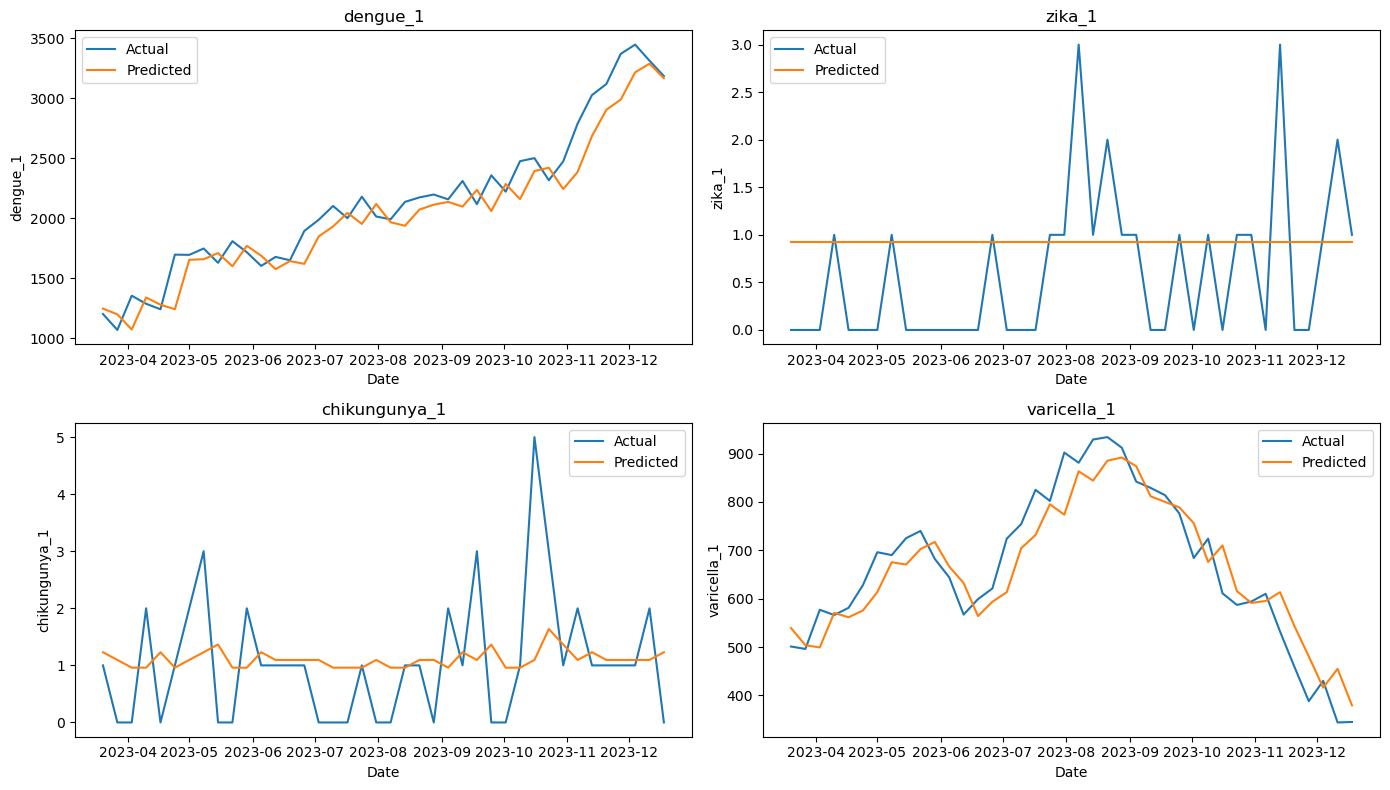

In [62]:


# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

targets = ['dengue_1', 'zika_1', 'chikungunya_1', 'varicella_1']
targets_lagged = {'dengue_1':'dengue',
                  'zika_1':'zika',
                  'chikungunya_1':'chikungunya',
                  'varicella_1':'varicella'}
targets_lagged_list = list(targets_lagged.values())

results       = []   # per‑target metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values for every row


# -------------------------------------------------------------
# 1.  Loop over target variables
# -------------------------------------------------------------
for tgt in targets:

    # ---- 1.1  Drop rows where THIS target is NaN
    df_tgt = (df.copy()
                .dropna(subset=[tgt])
                .sort_values('date')
                .reset_index(drop=True))

    if len(df_tgt) < 20:                            # too few points?
        print(f"[{tgt}] skipped (only {len(df_tgt)} non‑NaN rows)")
        continue

    # ---- 1.2  Features / target
    y = df_tgt[tgt]
    X = (df_tgt
         .drop(columns=targets + ['date'])          # drop ALL target cols + date
         .select_dtypes(include='number'))          # numeric predictors
    # drop epidemics that are not same as target
    targets_lagged_remove = targets_lagged_list.copy() # get a list of epidemics
    targets_lagged_remove.remove(targets_lagged[tgt]) # dont remove target epidemic (lagged)
    X = X.drop(columns=targets_lagged_remove) # remove other lagged epidemics

    
    # ---- 1.3 Chronological 80 / 20 split---------------
    split_pt = int(len(X) * 0.8)          # 80 % train, 20 % test
    train_idx = np.arange(split_pt)
    test_idx  = np.arange(split_pt, len(X))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_tgt.loc[test_idx, 'date']

    # ---- 1.4  Pipeline: scaler → LassoCV
    #           inner CV keeps order (3 folds on TRAIN only)
    inner_cv = TimeSeriesSplit(n_splits=3)

    lasso_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  LassoCV(cv=inner_cv,
                           random_state=42,
                           n_alphas=50,
                           max_iter=5000))
    ])

    lasso_pipe.fit(X_train, y_train)
    best_alpha = lasso_pipe.named_steps["model"].alpha_

    # ---- 1.5  Predict + metrics
    y_pred_test  = lasso_pipe.predict(X_test)
    y_pred_train = lasso_pipe.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({"target": tgt, "rmse": rmse, "r2": r2, "alpha": best_alpha})

    plot_payload.append({
        "target": tgt,
        "date":   dates_test,
        "y_true": y_test,
        "y_pred": y_pred_test
    })

    # ---- 1.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_tgt.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":   df_tgt['date'],
            "target": tgt,
            "fitted": y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 2.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 3.  Wide DataFrame of fitted values  (index = date, columns = targets)
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='target', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 4.  2 × 2 subplot grid of Actual vs. Predicted
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["target"])
    ax.set_xlabel("Date")
    ax.set_ylabel(payload["target"])
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [63]:
fitted_df.to_csv('../results/Lasso_epidemics.csv', index = True)

## Ridge

In [65]:
from sklearn.linear_model  import RidgeCV
df = df_og.copy()

          target        rmse        r2        alpha
0       dengue_1  178.532860  0.911766     0.001000
1         zika_1    0.823524 -0.059675   385.662042
2  chikungunya_1    1.092110  0.004005  1000.000000
3    varicella_1   57.791279  0.863906     0.001000
target      chikungunya_1    dengue_1  varicella_1    zika_1
date                                                        
2020-03-23       1.112204  864.158674   303.727504  1.170503
2020-03-30       1.202765  927.226514   242.487258  1.108245
2020-04-06       1.107303  878.258108   193.361012  1.119201
2020-04-13       1.049657  843.804956   178.252886  1.034428
2020-04-20       1.158054  835.903149   185.506326  1.080120


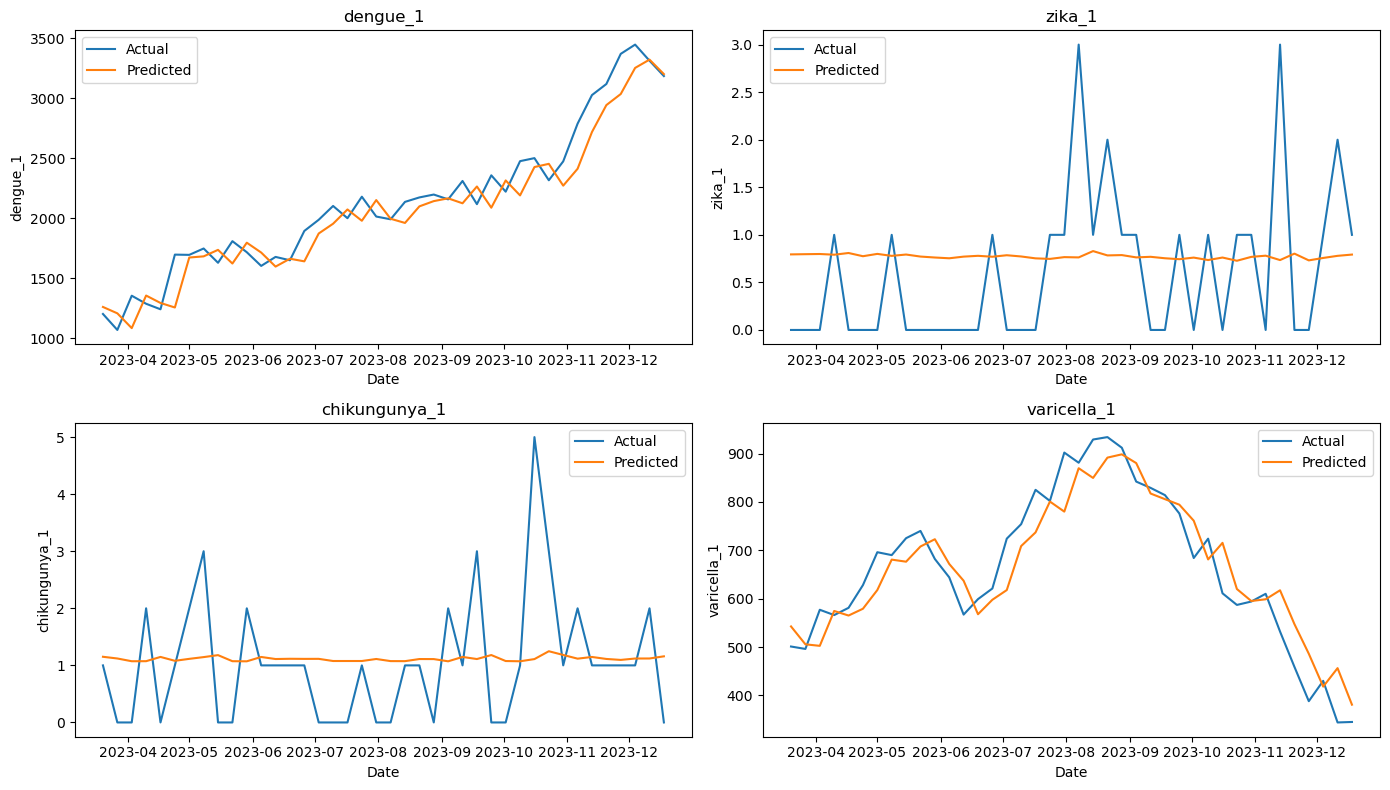

In [66]:


# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

targets = ['dengue_1', 'zika_1', 'chikungunya_1', 'varicella_1']
targets_lagged = {'dengue_1':'dengue',
                  'zika_1':'zika',
                  'chikungunya_1':'chikungunya',
                  'varicella_1':'varicella'}
targets_lagged_list = list(targets_lagged.values())

results       = []   # per‑target metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values for every row

# -------------------------------------------------------------
# 1.  Loop over target variables
# -------------------------------------------------------------
for tgt in targets:

    # ---- 1.1  Drop rows where THIS target is NaN
    df_tgt = (df.copy()
                .dropna(subset=[tgt])
                .sort_values('date')
                .reset_index(drop=True))

    if len(df_tgt) < 20:                            # too few points?
        print(f"[{tgt}] skipped (only {len(df_tgt)} non-NaN rows)")
        continue

    # ---- 1.2  Features / target
    y = df_tgt[tgt]
    X = (df_tgt
         .drop(columns=targets + ['date'])          # drop ALL target cols + date
         .select_dtypes(include='number'))          # numeric predictors
    # drop epidemics that are not same as target
    targets_lagged_remove = targets_lagged_list.copy() # get a list of epidemics
    targets_lagged_remove.remove(targets_lagged[tgt]) # dont remove target epidemic (lagged)
    X = X.drop(columns=targets_lagged_remove) # remove other lagged epidemics

    
    # ---- 1.3 Chronological 80 / 20 split---------------
    split_pt = int(len(X) * 0.8)          # 80 % train, 20 % test
    train_idx = np.arange(split_pt)
    test_idx  = np.arange(split_pt, len(X))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_tgt.loc[test_idx, 'date']

    # ---- 1.4  Pipeline: StandardScaler ➜ RidgeCV
    inner_cv   = TimeSeriesSplit(n_splits=3)   # CV folds on TRAIN only
    ridge_pipe = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model",  RidgeCV(alphas=np.logspace(-3, 3, 30),
                           cv=inner_cv,
                           scoring='neg_root_mean_squared_error'))
    ])

    ridge_pipe.fit(X_train, y_train)
    best_alpha = ridge_pipe.named_steps["model"].alpha_

    # ---- 1.5  Predict + metrics
    y_pred_test  = ridge_pipe.predict(X_test)
    y_pred_train = ridge_pipe.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({"target": tgt, "rmse": rmse, "r2": r2, "alpha": best_alpha})

    plot_payload.append({
        "target": tgt,
        "date":   dates_test,
        "y_true": y_test,
        "y_pred": y_pred_test
    })

    # ---- 1.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_tgt.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":   df_tgt['date'],
            "target": tgt,
            "fitted": y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 2.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 3.  Wide DataFrame of fitted values  (index = date, columns = targets)
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='target', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 4.  2 × 2 subplot grid of Actual vs. Predicted
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["target"])
    ax.set_xlabel("Date")
    ax.set_ylabel(payload["target"])
    ax.legend()

# Hide unused panels (if any)
for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [67]:
fitted_df.to_csv('../results/Ridge_epidemics.csv', index = True)

## ElasticNet

In [68]:

from sklearn.linear_model  import ElasticNetCV
df = df_og.copy()

          target        rmse        r2     alpha
0       dengue_1  191.933735  0.898022  0.028072
1         zika_1    0.862774 -0.163092  0.489390
2  chikungunya_1    1.085062  0.016819  0.303920
3    varicella_1   57.860035  0.863582  0.001000
target      chikungunya_1    dengue_1  varicella_1    zika_1
date                                                        
2020-03-23       1.096815  847.387099   303.402957  0.923077
2020-03-30       1.452477  908.335492   242.238592  0.923077
2020-04-06       1.215369  857.594933   193.109637  0.923077
2020-04-13       0.978261  827.867733   178.214870  0.923077
2020-04-20       1.333923  821.986408   185.497230  0.923077


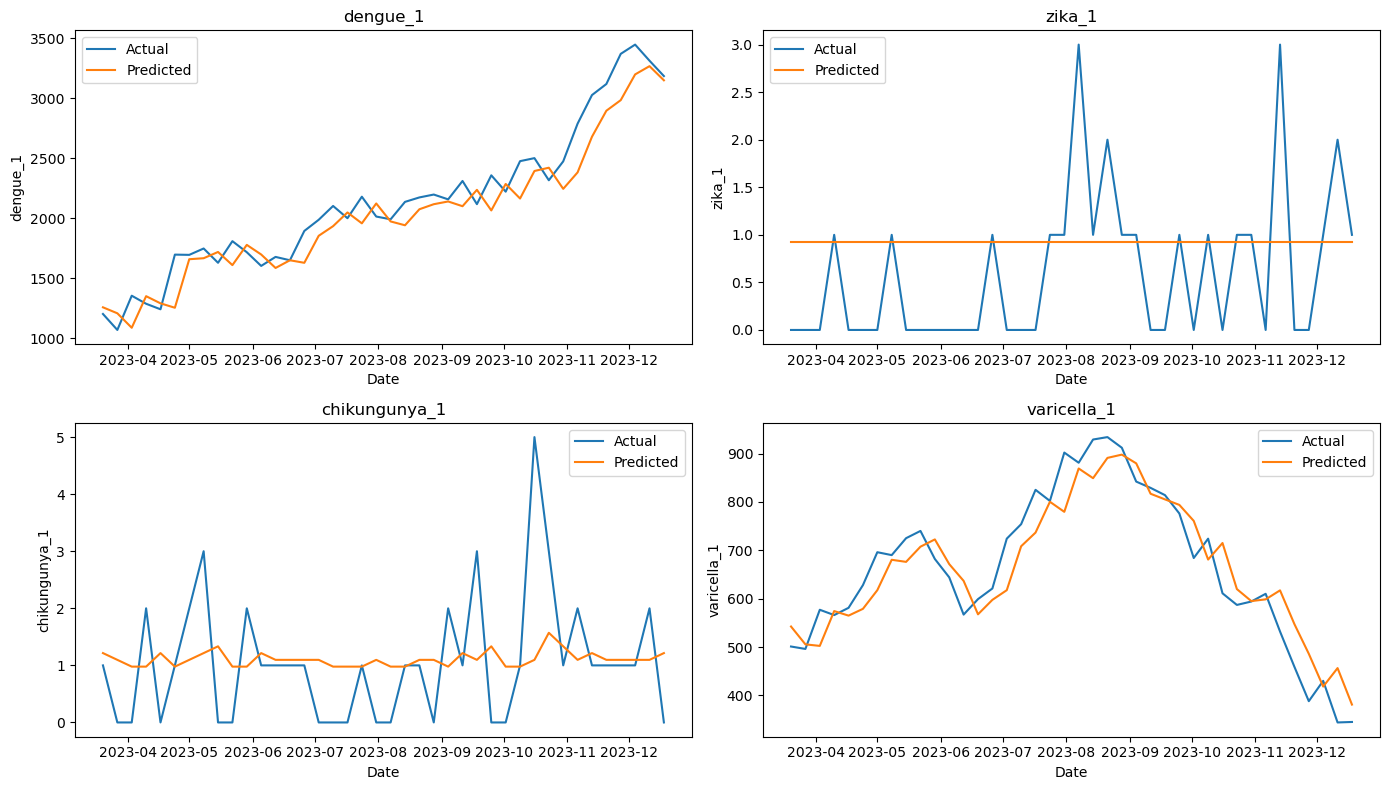

In [ ]:


# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

targets = ['dengue_1', 'zika_1', 'chikungunya_1', 'varicella_1']
targets_lagged = {'dengue_1':'dengue',
                  'zika_1':'zika',
                  'chikungunya_1':'chikungunya',
                  'varicella_1':'varicella'}
targets_lagged_list = list(targets_lagged.values())

results       = []   # per‑target metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values for every row

# -------------------------------------------------------------
# 1.  Loop over target variables
# -------------------------------------------------------------
for tgt in targets:

    # ---- 1.1  Drop rows where THIS target is NaN
    df_tgt = (df.copy()
                .dropna(subset=[tgt])
                .sort_values('date')
                .reset_index(drop=True))

    if len(df_tgt) < 20:
        print(f"[{tgt}] skipped (only {len(df_tgt)} non-NaN rows)")
        continue

    # ---- 1.2  Features / target
    y = df_tgt[tgt]
    X = (df_tgt
         .drop(columns=targets + ['date'])
         .select_dtypes(include='number'))
    # drop epidemics that are not same as target
    targets_lagged_remove = targets_lagged_list.copy() # get a list of epidemics
    targets_lagged_remove.remove(targets_lagged[tgt]) # dont remove target epidemic (lagged)
    X = X.drop(columns=targets_lagged_remove) # remove other lagged epidemics

    
    # ---- 1.3 Chronological 80 / 20 split---------------
    split_pt = int(len(X) * 0.8)          # 80 % train, 20 % test
    train_idx = np.arange(split_pt)
    test_idx  = np.arange(split_pt, len(X))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_tgt.loc[test_idx, 'date']

    # ---- 1.4  Pipeline: StandardScaler ➜ ElasticNetCV (l1_ratio = 0.5)
    inner_cv = TimeSeriesSplit(n_splits=3) # CV on TRAIN only
    enet_pipe = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model",  ElasticNetCV(
                      l1_ratio     = 0.5,                      # 50-50 mix
                      alphas       = np.logspace(-3, 3, 30),
                      cv           = inner_cv,
                      random_state = 42,
                      max_iter     = 5000))
    ])

    enet_pipe.fit(X_train, y_train)
    best_alpha = enet_pipe.named_steps["model"].alpha_

    # ---- 1.5  Predict + metrics
    y_pred_test  = enet_pipe.predict(X_test)
    y_pred_train = enet_pipe.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({"target": tgt, "rmse": rmse, "r2": r2, "alpha": best_alpha})

    plot_payload.append({
        "target": tgt,
        "date":   dates_test,
        "y_true": y_test,
        "y_pred": y_pred_test
    })

    # ---- 1.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_tgt.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":   df_tgt['date'],
            "target": tgt,
            "fitted": y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 2.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 3.  Wide DataFrame of fitted values  (index = date, columns = targets)
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='target', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 4.  2 × 2 subplot grid of Actual vs. Predicted
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["target"])
    ax.set_xlabel("Date")
    ax.set_ylabel(payload["target"])
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [70]:
fitted_df.to_csv('../results/ElasticNet_epidemics.csv', index = True)

## Random Forest

In [71]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble        import RandomForestRegressor
df = df_og.copy()

          target         rmse        r2  \
0       dengue_1  1018.609635 -1.872218   
1         zika_1     0.832478 -0.082842   
2  chikungunya_1     1.124412 -0.055784   
3    varicella_1   195.271819 -0.553794   

                                         best_params  
0  {'bootstrap': True, 'max_depth': 10, 'max_feat...  
1  {'bootstrap': True, 'max_depth': None, 'max_fe...  
2  {'bootstrap': True, 'max_depth': None, 'max_fe...  
3  {'bootstrap': True, 'max_depth': 10, 'max_feat...  
target      chikungunya_1    dengue_1  varicella_1    zika_1
date                                                        
2020-03-23       1.920566  966.079542   284.915000  1.751440
2020-03-30       1.927345  942.901667   214.266667  1.882501
2020-04-06       1.733744  908.745208   187.100354  1.718948
2020-04-13       1.672217  862.883500   188.497894  1.780690
2020-04-20       1.893623  826.026667   177.351378  1.471590


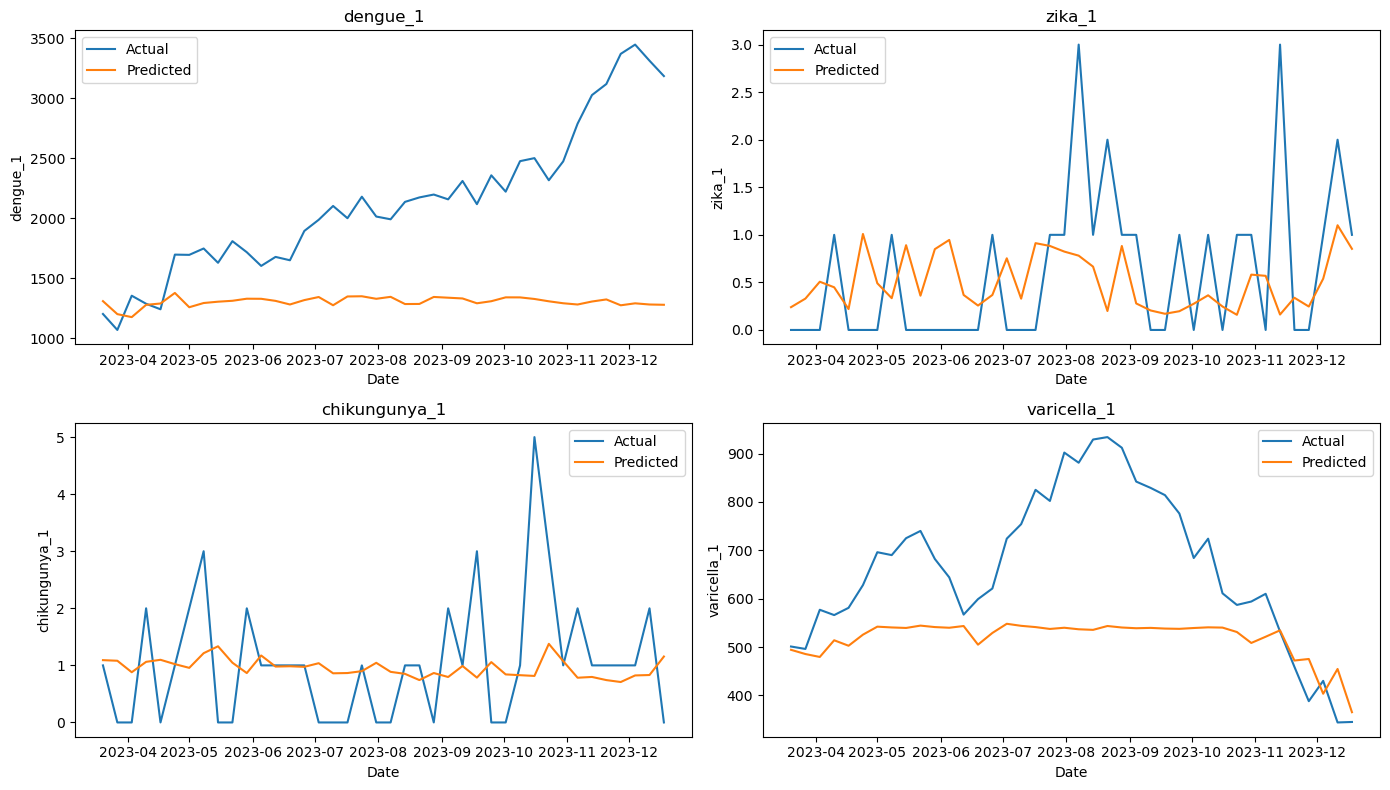

In [ ]:


# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

targets = ['dengue_1', 'zika_1', 'chikungunya_1', 'varicella_1']
targets_lagged = {'dengue_1':'dengue',
                  'zika_1':'zika',
                  'chikungunya_1':'chikungunya',
                  'varicella_1':'varicella'}
targets_lagged_list = list(targets_lagged.values())

results       = []   # per‑target metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values for every row
# -------------------------------------------------------------
# 1.  Hyper-parameter grid  (coarse → refine later)
# -------------------------------------------------------------
param_grid = {
    "n_estimators":      [400, 800, 1200],
    "max_depth":         [None, 10, 20],
    "max_features":      ["sqrt", 0.6],
    "min_samples_leaf":  [1, 3, 5],
    "bootstrap":         [True, False]
}

# -------------------------------------------------------------
# 2.  Loop over target variables
# -------------------------------------------------------------
for tgt in targets:

    # ---- 2.1  Drop rows where THIS target is NaN
    df_tgt = (df.copy()
                .dropna(subset=[tgt])
                .sort_values('date')
                .reset_index(drop=True))

    if len(df_tgt) < 20:                          # tiny series? skip
        print(f"[{tgt}] skipped (only {len(df_tgt)} non-NaN rows)")
        continue

    # ---- 2.2  Features / target
    y = df_tgt[tgt]
    X = (df_tgt
         .drop(columns=targets + ['date'])        # drop ALL targets + date
         .select_dtypes(include='number'))        # numeric predictors only
    
    # drop epidemics that are not same as target
    targets_lagged_remove = targets_lagged_list.copy() # get a list of epidemics
    targets_lagged_remove.remove(targets_lagged[tgt]) # dont remove target epidemic (lagged)
    X = X.drop(columns=targets_lagged_remove) # remove other lagged epidemics

    
    # ---- 1.3 Chronological 80 / 20 split---------------
    split_pt = int(len(X) * 0.8)          # 80 % train, 20 % test
    train_idx = np.arange(split_pt)
    test_idx  = np.arange(split_pt, len(X))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_tgt.loc[test_idx, 'date']


    # ---- 2.4  Inner CV: grid-search random forest on training part
    inner_cv = TimeSeriesSplit(n_splits=3)
    rf_base  = RandomForestRegressor(random_state=42, n_jobs=-1)

    grid = GridSearchCV(
        estimator   = rf_base,
        param_grid  = param_grid,
        cv          = inner_cv,
        scoring     = "neg_root_mean_squared_error",
        n_jobs      = -1,
        verbose     = 0
    )
    grid.fit(X_train, y_train)
    best_rf     = grid.best_estimator_
    best_params = grid.best_params_

    # ---- 2.5  Predict + metrics
    y_pred_test  = best_rf.predict(X_test)
    y_pred_train = best_rf.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({"target": tgt, "rmse": rmse, "r2": r2, "best_params": best_params})

    plot_payload.append({
        "target": tgt,
        "date":   dates_test,
        "y_true": y_test,
        "y_pred": y_pred_test
    })

    # ---- 2.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_tgt.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":   df_tgt['date'],
            "target": tgt,
            "fitted": y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 3.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 4.  Wide DataFrame of fitted values  (index = date, columns = targets)
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='target', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 5.  2 × 2 subplot grid of Actual vs. Predicted
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["target"])
    ax.set_xlabel("Date")
    ax.set_ylabel(payload["target"])
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [75]:
fitted_df.to_csv('../results/RF_epidemics.csv', index = True)

## Gradient Boosting

In [76]:
from sklearn.ensemble        import GradientBoostingRegressor
df = df_og.copy()

          target         rmse        r2  \
0       dengue_1  1022.630845 -1.894941   
1         zika_1     1.022992 -0.635176   
2  chikungunya_1     1.122732 -0.052633   
3    varicella_1   161.211513 -0.059025   

                                         best_params  
0  {'learning_rate': 0.1, 'max_depth': 2, 'max_fe...  
1  {'learning_rate': 0.03, 'max_depth': 2, 'max_f...  
2  {'learning_rate': 0.03, 'max_depth': 2, 'max_f...  
3  {'learning_rate': 0.03, 'max_depth': 2, 'max_f...  
target      chikungunya_1    dengue_1  varicella_1    zika_1
date                                                        
2020-03-23       2.400967  955.845815   284.743752  1.506988
2020-03-30       2.191861  943.157182   193.013644  2.334549
2020-04-06       1.653766  888.460460   174.319830  1.393551
2020-04-13       1.835660  871.331901   176.250019  1.960422
2020-04-20       1.981213  856.433941   172.934990  1.272095


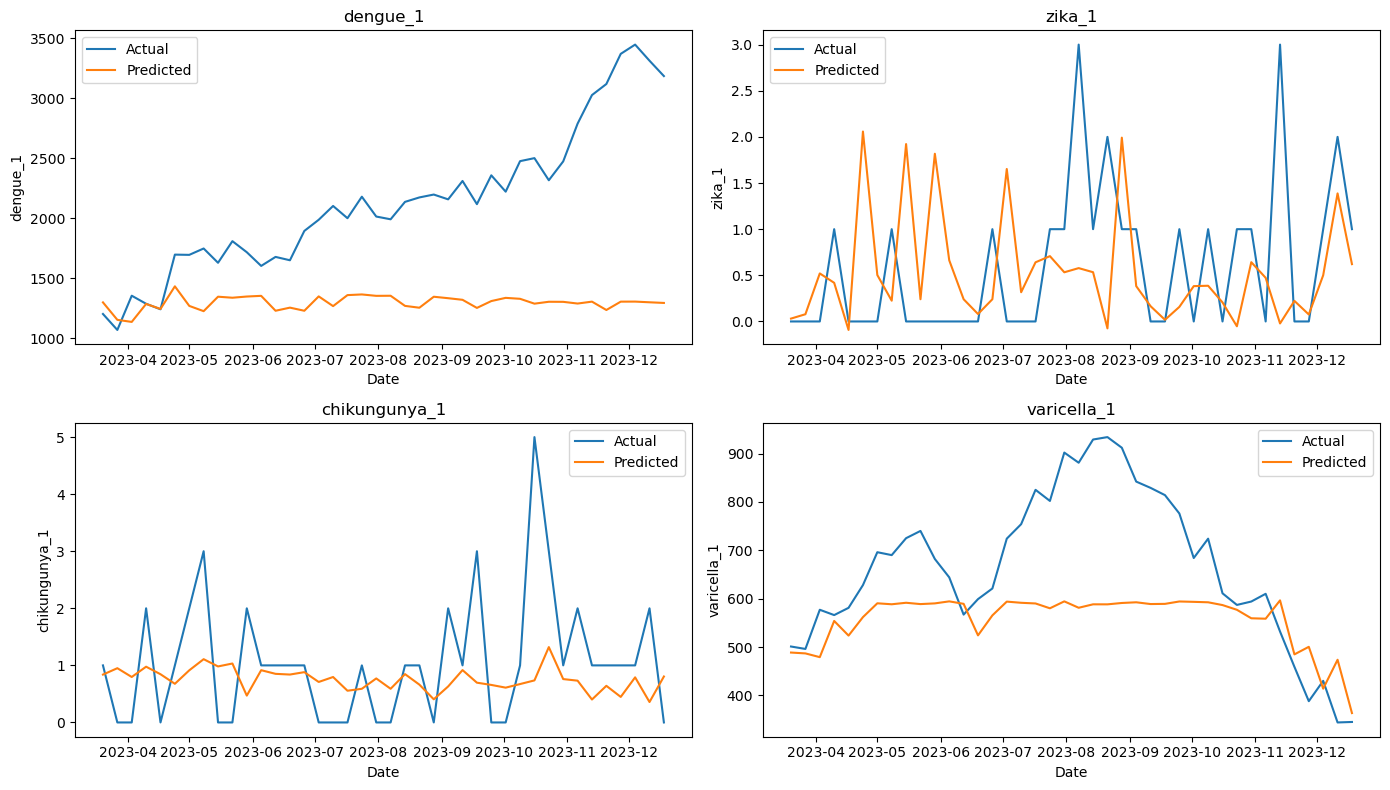

In [77]:


# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

targets = ['dengue_1', 'zika_1', 'chikungunya_1', 'varicella_1']
targets_lagged = {'dengue_1':'dengue',
                  'zika_1':'zika',
                  'chikungunya_1':'chikungunya',
                  'varicella_1':'varicella'}
targets_lagged_list = list(targets_lagged.values())

results       = []   # per‑target metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values for every row

# -------------------------------------------------------------
# 1.  Hyper-parameter grid  (coarse → refine once you see winners)
# -------------------------------------------------------------
param_grid = {
    "n_estimators":     [200, 400, 800],
    "learning_rate":    [0.03, 0.05, 0.1],
    "max_depth":        [2, 3, 4],
    "subsample":        [0.7, 0.9, 1.0],
    "min_samples_leaf": [1, 3, 5],
    "max_features":     ["sqrt", 0.6, None]
}

# -------------------------------------------------------------
# 2.  Loop over target variables
# -------------------------------------------------------------
for tgt in targets:

    # ---- 2.1  Drop rows where THIS target is NaN
    df_tgt = (df.copy()
                .dropna(subset=[tgt])
                .sort_values('date')
                .reset_index(drop=True))

    if len(df_tgt) < 20:                          # tiny series? skip
        print(f"[{tgt}] skipped (only {len(df_tgt)} non-NaN rows)")
        continue

    # ---- 2.2  Features / target
    y = df_tgt[tgt]
    X = (df_tgt
         .drop(columns=targets + ['date'])        # drop ALL target cols + date
         .select_dtypes(include='number'))        # numeric predictors only
    # drop epidemics that are not same as target
    targets_lagged_remove = targets_lagged_list.copy() # get a list of epidemics
    targets_lagged_remove.remove(targets_lagged[tgt]) # dont remove target epidemic (lagged)
    X = X.drop(columns=targets_lagged_remove) # remove other lagged epidemics

    
    # ---- 1.3 Chronological 80 / 20 split---------------
    split_pt = int(len(X) * 0.8)          # 80 % train, 20 % test
    train_idx = np.arange(split_pt)
    test_idx  = np.arange(split_pt, len(X))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_tgt.loc[test_idx, 'date']


    # ---- 2.4  Inner CV: grid-search GBM on training portion
    inner_cv = TimeSeriesSplit(n_splits=3)
    gb_base  = GradientBoostingRegressor(random_state=42)

    grid = GridSearchCV(
        estimator   = gb_base,
        param_grid  = param_grid,
        cv          = inner_cv,
        scoring     = "neg_root_mean_squared_error",
        n_jobs      = -1,
        verbose     = 0
    )
    grid.fit(X_train, y_train)
    best_gb     = grid.best_estimator_
    best_params = grid.best_params_

    # ---- 2.5  Predict + metrics
    y_pred_test  = best_gb.predict(X_test)
    y_pred_train = best_gb.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({"target": tgt, "rmse": rmse, "r2": r2, "best_params": best_params})

    plot_payload.append({
        "target": tgt,
        "date":   dates_test,
        "y_true": y_test,
        "y_pred": y_pred_test
    })

    # ---- 2.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_tgt.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":   df_tgt['date'],
            "target": tgt,
            "fitted": y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 3.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 4.  Wide DataFrame of fitted values  (index = date, columns = targets)
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='target', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 5.  2 × 2 subplot grid of Actual vs. Predicted
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["target"])
    ax.set_xlabel("Date")
    ax.set_ylabel(payload["target"])
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [78]:
fitted_df.to_csv('../results/GB_epidemics.csv', index = True)

## SVM

In [81]:
from sklearn.svm            import SVR
df = df_og.copy()

          target        rmse        r2  \
0       dengue_1  205.349091  0.883269   
1         zika_1    0.816489 -0.041648   
2  chikungunya_1    1.099912 -0.010276   
3    varicella_1   58.629681  0.859929   

                                         best_params  
0  {'model__C': 20, 'model__epsilon': 0.05, 'mode...  
1  {'model__C': 1, 'model__epsilon': 0.05, 'model...  
2  {'model__C': 1, 'model__epsilon': 0.05, 'model...  
3  {'model__C': 20, 'model__epsilon': 0.2, 'model...  
target      chikungunya_1    dengue_1  varicella_1    zika_1
date                                                        
2020-03-23       1.072593  843.122754   302.757382  1.117047
2020-03-30       1.133481  898.584590   240.710818  1.071851
2020-04-06       0.988144  833.802572   187.800000  1.012038
2020-04-13       0.967019  816.705547   171.189819  1.096937
2020-04-20       1.049921  815.738458   179.779070  1.103664


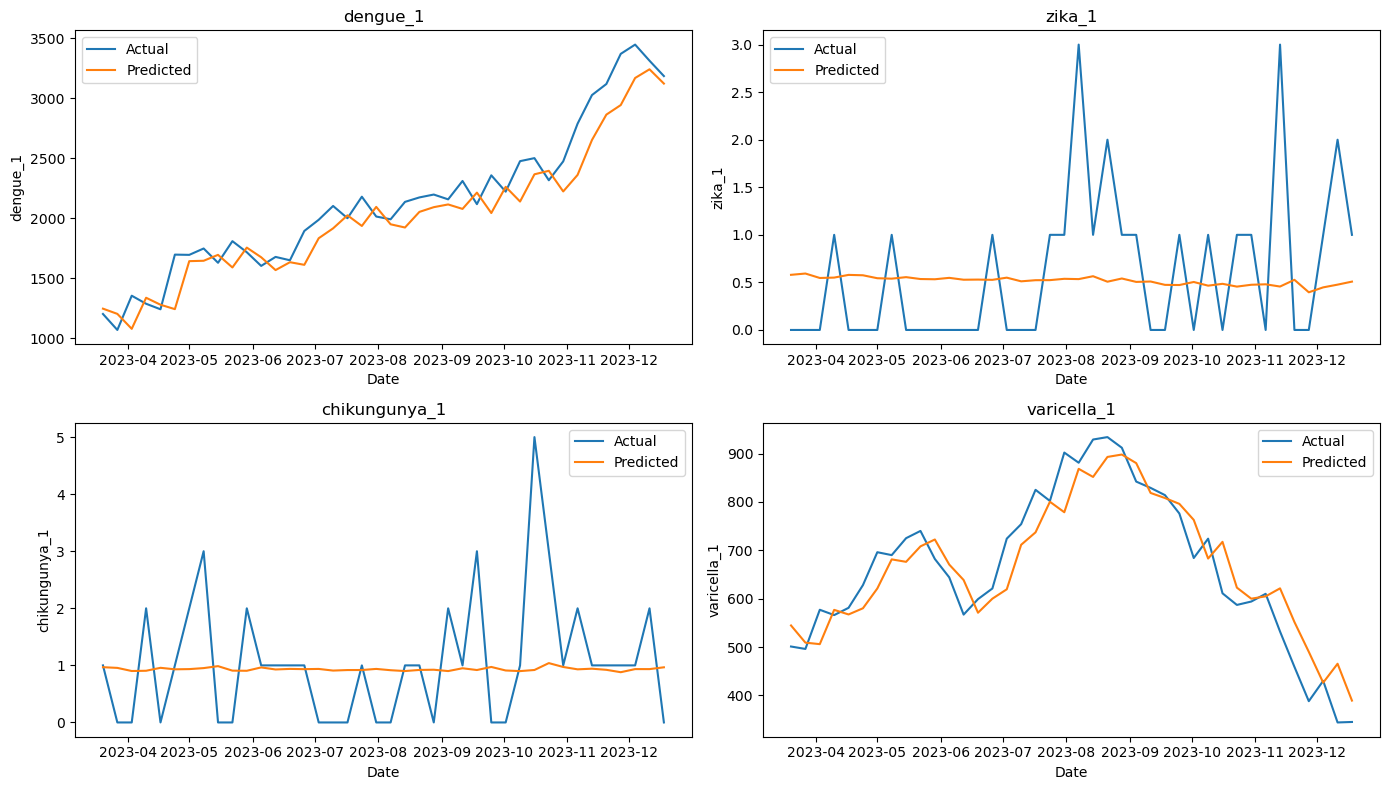

In [82]:



# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

targets = ['dengue_1', 'zika_1', 'chikungunya_1', 'varicella_1']
targets_lagged = {'dengue_1':'dengue',
                  'zika_1':'zika',
                  'chikungunya_1':'chikungunya',
                  'varicella_1':'varicella'}
targets_lagged_list = list(targets_lagged.values())

results       = []   # per‑target metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values for every row

# -------------------------------------------------------------
# 1.  Hyper-parameter grid for an RBF-kernel SVR
# -------------------------------------------------------------
param_grid = [
    {   # RBF search
        "model__kernel":  ["rbf"],
        "model__C":       [0.5, 1, 5, 20],
        "model__epsilon": [0.05, 0.1, 0.2],
        "model__gamma":   ["scale", 0.01, 0.1, 1.0],
    },
    {   # Linear search (no gamma)
        "model__kernel":  ["linear"],
        "model__C":       [0.5, 1, 5, 20],
        "model__epsilon": [0.05, 0.1, 0.2],
    },
]

# -------------------------------------------------------------
# 2.  Loop over target variables
# -------------------------------------------------------------
for tgt in targets:

    # ---- 2.1  Drop rows where THIS target is NaN
    df_tgt = (
        df.dropna(subset=[tgt])
          .sort_values('date')
          .reset_index(drop=True)
    )

    if len(df_tgt) < 20:
        print(f"[{tgt}] skipped (only {len(df_tgt)} non-NaN rows)")
        continue

    # ---- 2.2  Features / target
    y = df_tgt[tgt]
    X = (
        df_tgt
        .drop(columns=targets + ['date'])     # remove ALL target cols + date
        .select_dtypes(include='number')      # numeric predictors only
    )
    # drop epidemics that are not same as target
    targets_lagged_remove = targets_lagged_list.copy() # get a list of epidemics
    targets_lagged_remove.remove(targets_lagged[tgt]) # dont remove target epidemic (lagged)
    X = X.drop(columns=targets_lagged_remove) # remove other lagged epidemics

    
    # ---- 2.3 Chronological 80 / 20 split---------------
    split_pt = int(len(X) * 0.8)          # 80 % train, 20 % test
    train_idx = np.arange(split_pt)
    test_idx  = np.arange(split_pt, len(X))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_tgt.loc[test_idx, 'date']



    # ---- 2.4  Pipeline: StandardScaler ➜ SVR + grid search
    inner_cv = TimeSeriesSplit(n_splits=3)

    svr_pipe = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model",  SVR())
        ]
    )

    grid = GridSearchCV(
        estimator   = svr_pipe,
        param_grid  = param_grid,
        cv          = inner_cv,
        scoring     = "neg_root_mean_squared_error",
        n_jobs      = -1,
        verbose     = 0,
    )
    grid.fit(X_train, y_train)

    best_svr    = grid.best_estimator_
    best_params = grid.best_params_

    # ---- 2.5  Predict + metrics
    y_pred_test  = best_svr.predict(X_test)
    y_pred_train = best_svr.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({
        "target":     tgt,
        "rmse":       rmse,
        "r2":         r2,
        "best_params": best_params
    })

    plot_payload.append({
        "target": tgt,
        "date":   dates_test,
        "y_true": y_test,
        "y_pred": y_pred_test
    })

    # ---- 2.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_tgt.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":   df_tgt['date'],
            "target": tgt,
            "fitted": y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 3.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 4.  Wide DataFrame of fitted values (index = date, columns = targets)
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='target', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 5.  2 × 2 subplot grid of Actual vs. Predicted
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["target"])
    ax.set_xlabel("Date")
    ax.set_ylabel(payload["target"])
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [83]:
fitted_df.to_csv('../results/SVM_epidemics.csv', index = True)

They depend almost exclusively on their lagged variables, so modelling as VAR is a good Idea / or any other time series approach as has been done until now